In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import WhisperForAudioClassification, WhisperProcessor
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score, classification_report, balanced_accuracy_score
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import time
from tqdm import tqdm
import librosa
import random
from sklearn.model_selection import KFold

/home/fnst/Desktop/shendabadi/whisper_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if torch.cuda.is_available():
  device = 'cuda'
else:
  device = 'cpu'

device

'cuda'

In [5]:
# Defining a function to set or change the seed for random number generation at each step.

def reset_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available:
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [6]:
whisper_tiny_processor = WhisperProcessor.from_pretrained('whisper_small')

In [7]:
reset_seed(42)
emo2num = {
    'H' : 0,
    'N' : 1,
    'S' : 2,
    'A' : 3,
    'W' : 4
}

num2emo = {
    0 : 'Happy',
    1 : 'Neutral',
    2 : 'Sad',
    3 : 'Anger',
    4 : 'Wonder'
}


audios = []
sample_rates = []
emotions = []
labels = []
file_names = []
file_paths = []
features = []

pattern = r'^...(.)'

for root, folders, files in os.walk('shemo'):
    for filename in files:
        file_path = os.path.join(root, filename)
        audio_data, sr = librosa.load(file_path, sr=16000)
        
        input_features = whisper_tiny_processor(audio_data, sampling_rate=sr, return_tensors="pt").input_features
    

        match = re.search(pattern, filename)
        if match:
            char = match.group(1)
            if char in ['H', 'N', 'S', 'W', 'A']:
                audios.append(audio_data)
                sample_rates.append(sr)
                # emotion = 'H' if char == 'W' else char
                emotion = char
                label = emo2num[emotion]

                emotions.append(emotion)
                labels.append(label)
                features.append(input_features.squeeze(0))
                file_names.append(filename)
                file_paths.append(file_path)

In [8]:
kf = KFold(n_splits=5, random_state=42, shuffle=True)
kf.get_n_splits(features)

5

In [9]:
for i, (train_index, test_index) in enumerate(kf.split(features)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")

Fold 0:
  Train: index=[   0    1    2 ... 2958 2959 2960]
  Test:  index=[   7   12   29   30   32   43   44   45   51   56   63   67   70   73
   80   87   93   96  102  104  108  111  120  124  134  135  139  141
  144  149  152  162  168  170  173  174  175  177  178  183  184  188
  192  194  196  199  203  210  211  212  218  221  226  231  233  239
  246  251  254  256  257  270  272  282  283  289  291  296  298  309
  313  314  318  321  322  324  331  332  351  354  365  366  367  368
  387  393  402  407  408  410  411  414  415  420  422  423  430  432
  433  436  439  443  450  457  460  463  464  471  478  479  485  486
  495  498  506  507  509  511  521  527  528  532  533  535  543  544
  554  555  557  564  565  567  568  572  581  594  598  599  602  605
  610  612  637  642  644  650  651  670  676  677  678  679  685  693
  695  700  705  727  736  741  742  744  746  748  761  764  765  772
  781  783  785  789  807  809  811  817  819  829  838  839  840  842
  8

In [10]:
(train_index1, test_index1), (train_index2, test_index2),(train_index3, test_index3),(train_index4, test_index4),(train_index5, test_index5) = kf.split(features)

In [11]:
trainF1features = [value for index, value in enumerate(features) if index in train_index1]
trainF2features = [value for index, value in enumerate(features) if index in train_index2]
trainF3features = [value for index, value in enumerate(features) if index in train_index3]
trainF4features = [value for index, value in enumerate(features) if index in train_index4]
trainF5features = [value for index, value in enumerate(features) if index in train_index5]

trainF1labels = [value for index, value in enumerate(labels) if index in train_index1]
trainF2labels = [value for index, value in enumerate(labels) if index in train_index2]
trainF3labels = [value for index, value in enumerate(labels) if index in train_index3]
trainF4labels = [value for index, value in enumerate(labels) if index in train_index4]
trainF5labels = [value for index, value in enumerate(labels) if index in train_index5]

testF1features = [value for index, value in enumerate(features) if index in test_index1]
testF2features = [value for index, value in enumerate(features) if index in test_index2]
testF3features = [value for index, value in enumerate(features) if index in test_index3]
testF4features = [value for index, value in enumerate(features) if index in test_index4]
testF5features = [value for index, value in enumerate(features) if index in test_index5]

testF1labels = [value for index, value in enumerate(labels) if index in test_index1]
testF2labels = [value for index, value in enumerate(labels) if index in test_index2]
testF3labels = [value for index, value in enumerate(labels) if index in test_index3]
testF4labels = [value for index, value in enumerate(labels) if index in test_index4]
testF5labels = [value for index, value in enumerate(labels) if index in test_index5]

In [12]:
reset_seed(42)
class AudioDataSet(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        # Assuming features[index] is a processed audio feature and labels[index] is the corresponding label
        sample = {
            'feature': torch.Tensor(self.features[index]),  # Convert to PyTorch tensor if not already
            'label': torch.Tensor([self.labels[index]])  # Convert to PyTorch tensor if not already
        }

        return sample


Fold1train = AudioDataSet(trainF1features, trainF1labels)
Fold1test = AudioDataSet(testF1features, testF1labels)

Fold2train = AudioDataSet(trainF2features, trainF2labels)
Fold2test = AudioDataSet(testF2features, testF2labels)

Fold3train = AudioDataSet(trainF3features, trainF3labels)
Fold3test = AudioDataSet(testF3features, testF3labels)

Fold4train = AudioDataSet(trainF4features, trainF4labels)
Fold4test = AudioDataSet(testF4features, testF4labels)

Fold5train = AudioDataSet(trainF5features, trainF5labels)
Fold5test = AudioDataSet(testF5features, testF5labels)



# Example of using DataLoader for batching
train_loaderF1 = DataLoader(Fold1train, batch_size=4, shuffle=True)
val_loaderF1 = DataLoader(Fold1test, batch_size=4, shuffle=False)

train_loaderF2 = DataLoader(Fold2train, batch_size=4, shuffle=True)
val_loaderF2 = DataLoader(Fold2test, batch_size=4, shuffle=False)

train_loaderF3 = DataLoader(Fold3train, batch_size=4, shuffle=True)
val_loaderF3 = DataLoader(Fold3test, batch_size=4, shuffle=False)

train_loaderF4 = DataLoader(Fold4train, batch_size=4, shuffle=True)
val_loaderF4 = DataLoader(Fold4test, batch_size=4, shuffle=False)

train_loaderF5 = DataLoader(Fold5train, batch_size=4, shuffle=True)
val_loaderF5 = DataLoader(Fold5test, batch_size=4, shuffle=False)

In [13]:
loader_lists = [(train_loaderF1, val_loaderF1), (train_loaderF2, val_loaderF2), (train_loaderF3, val_loaderF3), (train_loaderF4, val_loaderF4), (train_loaderF5, val_loaderF5)]

In [14]:
reset_seed(42)
def train(model, model_name, optimizer, loss_fn, train_loader, val_loader, epochs =40, patience=4):
  training_losses = []
  valid_losses = []
  durations = []
  best_val_loss = float('inf')
  current_patience = 0

  for epoch in range(epochs):
    training_loss = []
    valid_loss = []
    start_time = time.time()

    model.train()
    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}', leave=False): # Each batch, One Iteration
      optimizer.zero_grad()
      inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()
      inputs, targets = inputs.to(device), targets.to(device)
      batch_size = inputs.size(0)
      h = model.init_hidden(batch_size).to(device)
      output = model(inputs, h)
      loss = loss_fn(output, targets)
      loss.backward()
      optimizer.step()
      inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration

      training_loss.append(loss.data.item())
    training_loss = np.mean(training_loss)
    training_losses.append(training_loss)
    

    model.eval()
    num_correct = 0
    num_examples = 0
    for batch in tqdm(val_loader, desc=f'Epoch {epoch}/{epochs}', leave=False):
      inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()
      inputs, targets = inputs.to(device), targets.to(device)
      batch_size = inputs.size(0)
      h = model.init_hidden(batch_size).to(device)
      output = model(inputs, h)
      loss = loss_fn(output, targets)
      valid_loss.append(loss.data.item())
      correct = torch.eq(torch.argmax(F.softmax(output, dim=1), dim=1), targets.view(-1))
      num_correct += torch.sum(correct).item()
      num_examples += correct.shape[0]
      inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration
      
    valid_loss = np.mean(valid_loss)
    valid_losses.append(valid_loss)
    end_time = time.time()
    duration = end_time - start_time
    durations.append(duration)

    print(f'Epoch: {epoch+1} finished in {duration:.2f} seconds, Training Loss: {training_loss: .2f}, Validation Loss: {valid_loss:.2f}, Validation Accuracy: {num_correct / num_examples : .2f}')

    # Check for improvement
    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        torch.save(model.state_dict(), f'{model_name}.bin') # Saving the best model because I want to use the best checkpoints of the model to test it
        current_patience = 0
    else:
        current_patience += 1

    # Early stopping logic
    if current_patience >= patience:
        print(f"Early stopping at epoch {epoch+1}. Because Validation loss increased for {patience} consecutive epochs.")
        break

  print(f"Each epoch took {np.mean(durations):.2f} seconds in average.")

  return training_losses, valid_losses

In [15]:
def test(model, loss_fn, test_loader):
  model.eval()
  test_loss = []
  labels = []
  preds = []
  for batch in test_loader:
    inputs, targets = batch['feature'], batch['label'].squeeze(-1).long()

    for target in targets:
      labels.append(target.item())
    inputs, targets = inputs.to(device), targets.to(device)
    batch_size = inputs.size(0)
    h = model.init_hidden(batch_size).to(device)
    output = model(inputs, h)
    for out in output:
      preds.append(torch.argmax(F.softmax(out, dim=0), dim=0).item())
    loss = loss_fn(output, targets)
    test_loss.append(loss.data.item())
    inputs, targets, output = inputs.to('cpu'), targets.to('cpu'), output.to('cpu') # Return tensors to cpu after each iteration


  #######################################################################################################
  accuracy_per_class = {}
  unique_classes = set(labels)
  for class_label in unique_classes:
      indices = [i for i, y in enumerate(labels) if y == class_label]
      class_accuracy = accuracy_score([labels[i] for i in indices], [preds[i] for i in indices])
      accuracy_per_class[class_label] = class_accuracy

  w_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  #######################################################################################################


  test_loss = np.mean(test_loss)
  w_acc = accuracy_score(labels, preds)
  u_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  precision = precision_score(labels, preds, average='weighted')
  recall = recall_score(labels, preds, average='weighted')
  f1 = f1_score(labels, preds, average='weighted')
  cm = confusion_matrix(labels, preds)
  sns.set(font_scale=1.2)  # Adjust the font scale for better readability
  sns.heatmap(cm, annot=True, fmt='g', cmap='Greens', 
              xticklabels=['Happy', 'Neutral', 'Sad', 'Anger', 'Wonder'], 
              yticklabels=['Happy', 'Neutral', 'Sad', 'Anger', 'Wonder'])
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

  print(f'Testing finished with Loss: {test_loss} | U_Accuracy: {u_acc} | W_Accuracy: {w_acc} | Precision: {precision} | Recall: {recall} | f1: {f1}')

  print("Accuracy per class:")
  for class_label, accuracy in accuracy_per_class.items():
      print(f"Class {class_label}: {accuracy}")

In [16]:
reset_seed(42)

class GRUModel (nn.Module):
  def __init__(self, hidden_size=256, num_layers=1, b_directional=False):
    super(GRUModel, self).__init__()
    self.whisperencoder = WhisperForAudioClassification.from_pretrained('whisper_small').encoder.to(device)
    self.projector = WhisperForAudioClassification.from_pretrained('whisper_small').projector.to(device)
    self.hidden_size = hidden_size
    self.num_layers = num_layers
    if b_directional == True: self.d = 2
    elif b_directional == False: self.d = 1
    self.gru = torch.nn.GRU(256, hidden_size=hidden_size, num_layers=num_layers, bias=True, batch_first=True, dropout=0.0, bidirectional=b_directional, device=device)
    self.classifier = torch.nn.Linear(in_features=self.d*hidden_size, out_features=5)

  def forward(self, x, h0):
    out = self.whisperencoder(x).last_hidden_state
    out = self.projector(out)
    out, _ = self.gru(out, h0)
    out = self.classifier(out[:, -1, :])  # Take the output from the last time step
    return out
  
  def init_hidden(self, batch_size):
    return torch.zeros(self.d * self.num_layers, batch_size, self.hidden_size)

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch: 1 finished in 178.63 seconds, Training Loss:  1.27, Validation Loss: 0.95, Validation Accuracy:  0.66


Epoch: 2 finished in 178.76 seconds, Training Loss:  0.88, Validation Loss: 0.83, Validation Accuracy:  0.68


Epoch: 3 finished in 178.76 seconds, Training Loss:  0.71, Validation Loss: 0.61, Validation Accuracy:  0.79


Epoch: 4 finished in 178.73 seconds, Training Loss:  0.58, Validation Loss: 0.65, Validation Accuracy:  0.77


...

Epoch: 6 finished in 178.76 seconds, Training Loss:  0.45, Validation Loss: 0.49, Validation Accuracy:  0.83


Epoch: 7 finished in 178.78 seconds, Training Loss:  0.41, Validation Loss: 0.52, Validation Accuracy:  0.82


Epoch: 8 finished in 178.77 seconds, Training Loss:  0.37, Validation Loss: 0.52, Validation Accuracy:  0.84


Epoch: 9 finished in 178.76 seconds, Training Loss:  0.33, Validation Loss: 0.52, Validation Accuracy:  0.83


Epoch: 10 finished in 178.75 seconds, Training Loss:  0.32, Validation Loss: 0.49, Validation Accuracy:  0.84
Each epoch took 178.75 seconds in average.


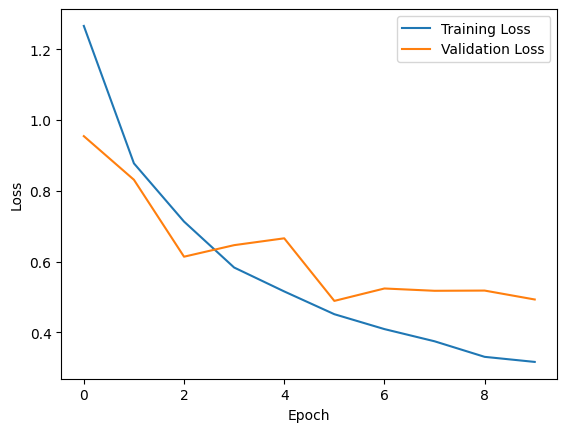

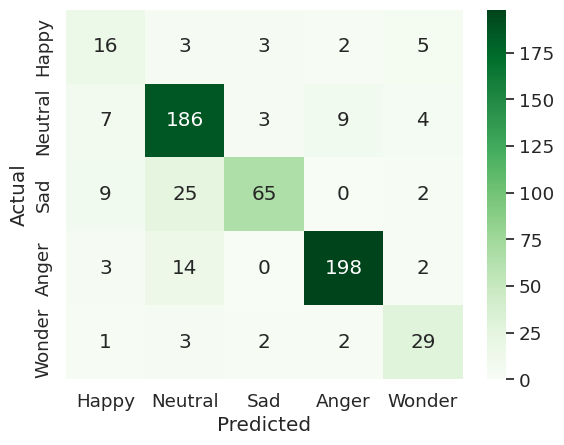

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.4887207601494437 | U_Accuracy: 0.7562933655147748 | W_Accuracy: 0.8330522765598651 | Precision: 0.843649343718536 | Recall: 0.8330522765598651 | f1: 0.8336879444999501
Accuracy per class:
Class 0: 0.5517241379310345
Class 1: 0.8899521531100478
Class 2: 0.6435643564356436
Class 3: 0.9124423963133641
Class 4: 0.7837837837837838


Epoch: 1 finished in 178.96 seconds, Training Loss:  1.21, Validation Loss: 0.91, Validation Accuracy:  0.70


Epoch: 2 finished in 178.91 seconds, Training Loss:  0.76, Validation Loss: 0.91, Validation Accuracy:  0.67


Epoch: 3 finished in 178.94 seconds, Training Loss:  0.64, Validation Loss: 0.63, Validation Accuracy:  0.78


...

Epoch: 6 finished in 178.90 seconds, Training Loss:  0.43, Validation Loss: 0.57, Validation Accuracy:  0.80


Epoch: 7 finished in 178.91 seconds, Training Loss:  0.40, Validation Loss: 0.55, Validation Accuracy:  0.82


Epoch: 8 finished in 178.89 seconds, Training Loss:  0.37, Validation Loss: 0.65, Validation Accuracy:  0.78


Epoch: 9 finished in 178.86 seconds, Training Loss:  0.36, Validation Loss: 0.53, Validation Accuracy:  0.82


Epoch: 10 finished in 178.85 seconds, Training Loss:  0.33, Validation Loss: 0.54, Validation Accuracy:  0.82
Each epoch took 178.90 seconds in average.


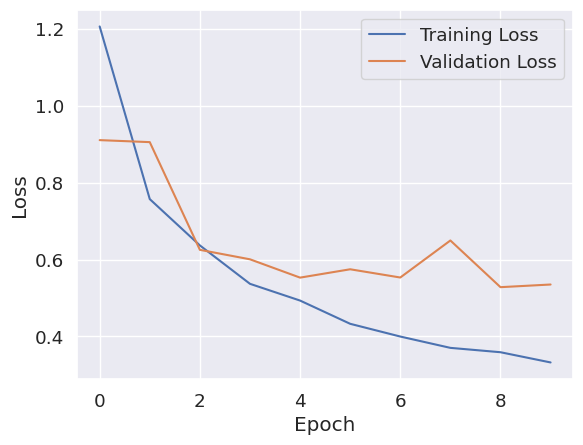

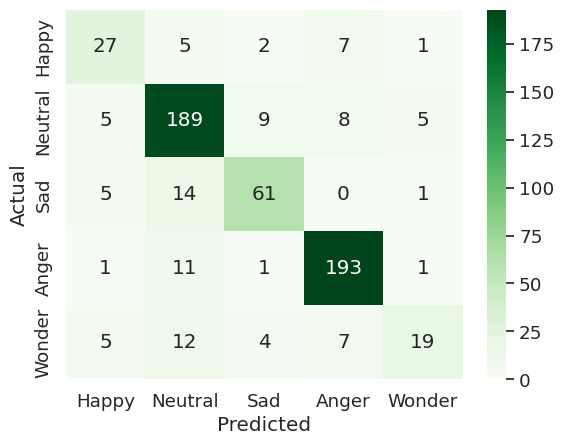

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.5280956828704216 | U_Accuracy: 0.721513206303524 | W_Accuracy: 0.8246205733558178 | Precision: 0.8198328425709892 | Recall: 0.8246205733558178 | f1: 0.8184835450625185
Accuracy per class:
Class 0: 0.6428571428571429
Class 1: 0.875
Class 2: 0.7530864197530864
Class 3: 0.9323671497584541
Class 4: 0.40425531914893614


Epoch: 1 finished in 178.86 seconds, Training Loss:  1.22, Validation Loss: 1.14, Validation Accuracy:  0.55


Epoch: 2 finished in 178.78 seconds, Training Loss:  0.76, Validation Loss: 0.71, Validation Accuracy:  0.76


Epoch: 3 finished in 178.78 seconds, Training Loss:  0.61, Validation Loss: 0.58, Validation Accuracy:  0.81


...

Epoch: 6 finished in 178.86 seconds, Training Loss:  0.42, Validation Loss: 0.52, Validation Accuracy:  0.81


Epoch: 7 finished in 178.81 seconds, Training Loss:  0.37, Validation Loss: 0.56, Validation Accuracy:  0.79


Epoch: 8 finished in 178.80 seconds, Training Loss:  0.35, Validation Loss: 0.51, Validation Accuracy:  0.83


Epoch: 9 finished in 178.80 seconds, Training Loss:  0.31, Validation Loss: 0.56, Validation Accuracy:  0.80


Epoch: 10 finished in 178.80 seconds, Training Loss:  0.30, Validation Loss: 0.50, Validation Accuracy:  0.84
Each epoch took 178.81 seconds in average.


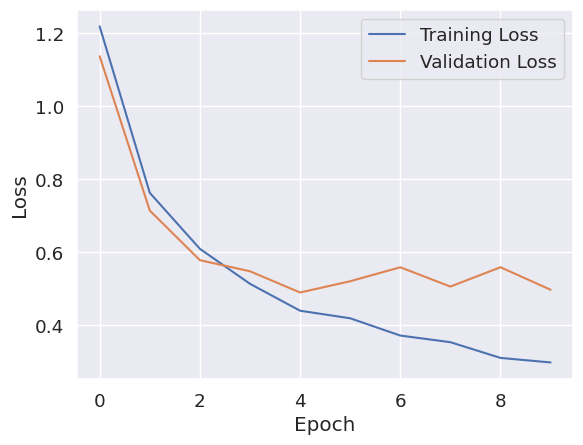

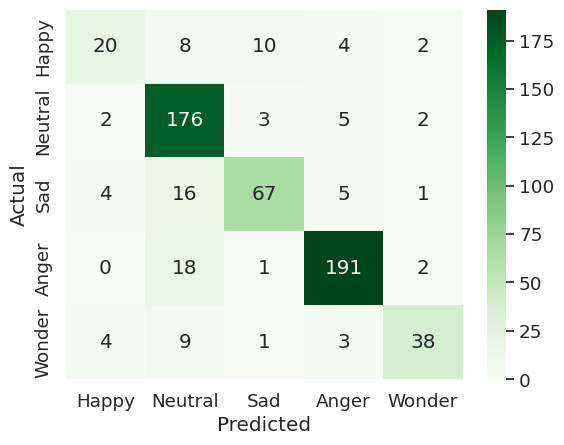

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.49020487939737534 | U_Accuracy: 0.7405996523947599 | W_Accuracy: 0.831081081081081 | Precision: 0.8314202265478858 | Recall: 0.831081081081081 | f1: 0.8261393596927624
Accuracy per class:
Class 0: 0.45454545454545453
Class 1: 0.9361702127659575
Class 2: 0.7204301075268817
Class 3: 0.9009433962264151
Class 4: 0.6909090909090909


Epoch: 1 finished in 178.91 seconds, Training Loss:  1.16, Validation Loss: 0.96, Validation Accuracy:  0.67


Epoch: 2 finished in 178.83 seconds, Training Loss:  0.75, Validation Loss: 0.68, Validation Accuracy:  0.76


Epoch: 3 finished in 178.86 seconds, Training Loss:  0.62, Validation Loss: 0.70, Validation Accuracy:  0.73


...

Epoch: 6 finished in 178.82 seconds, Training Loss:  0.43, Validation Loss: 0.52, Validation Accuracy:  0.81


Epoch: 7 finished in 178.81 seconds, Training Loss:  0.40, Validation Loss: 0.51, Validation Accuracy:  0.84


Epoch: 8 finished in 178.85 seconds, Training Loss:  0.38, Validation Loss: 0.55, Validation Accuracy:  0.83


Epoch: 9 finished in 178.86 seconds, Training Loss:  0.35, Validation Loss: 0.56, Validation Accuracy:  0.81


Epoch: 10 finished in 178.84 seconds, Training Loss:  0.34, Validation Loss: 0.47, Validation Accuracy:  0.84
Each epoch took 178.85 seconds in average.


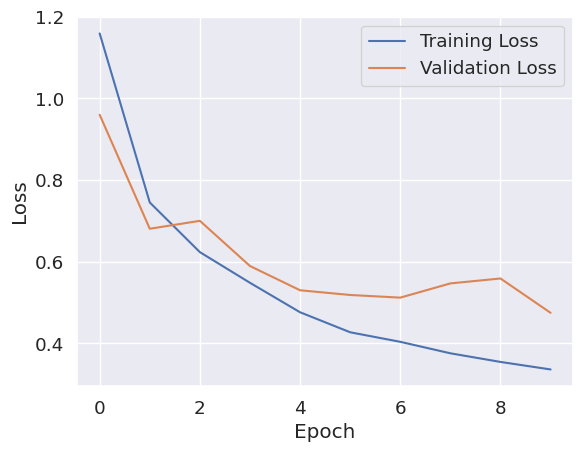

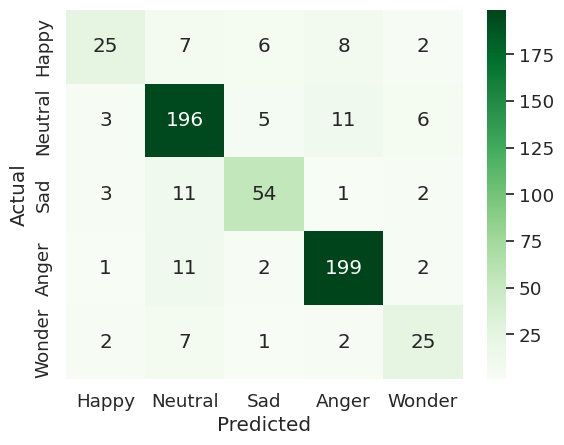

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_small and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testing finished with Loss: 0.47496036537041936 | U_Accuracy: 0.753906322538767 | W_Accuracy: 0.8429054054054054 | Precision: 0.8394943449456634 | Recall: 0.8429054054054054 | f1: 0.8394186592910128
Accuracy per class:
Class 0: 0.5208333333333334
Class 1: 0.8868778280542986
Class 2: 0.7605633802816901
Class 3: 0.9255813953488372
Class 4: 0.6756756756756757


Epoch: 1 finished in 178.85 seconds, Training Loss:  1.23, Validation Loss: 0.94, Validation Accuracy:  0.67


Epoch: 2 finished in 178.80 seconds, Training Loss:  0.79, Validation Loss: 0.64, Validation Accuracy:  0.80


Epoch: 3 finished in 178.81 seconds, Training Loss:  0.62, Validation Loss: 0.60, Validation Accuracy:  0.81


...

Epoch: 6 finished in 178.86 seconds, Training Loss:  0.45, Validation Loss: 0.56, Validation Accuracy:  0.81


Epoch: 7 finished in 178.87 seconds, Training Loss:  0.41, Validation Loss: 0.52, Validation Accuracy:  0.84


Epoch: 8 finished in 178.84 seconds, Training Loss:  0.38, Validation Loss: 0.49, Validation Accuracy:  0.84


Epoch: 9 finished in 178.88 seconds, Training Loss:  0.37, Validation Loss: 0.48, Validation Accuracy:  0.84


Epoch: 10 finished in 178.81 seconds, Training Loss:  0.33, Validation Loss: 0.46, Validation Accuracy:  0.86
Each epoch took 178.84 seconds in average.


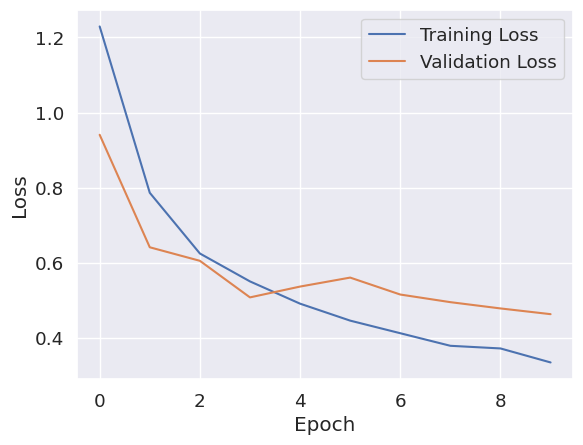

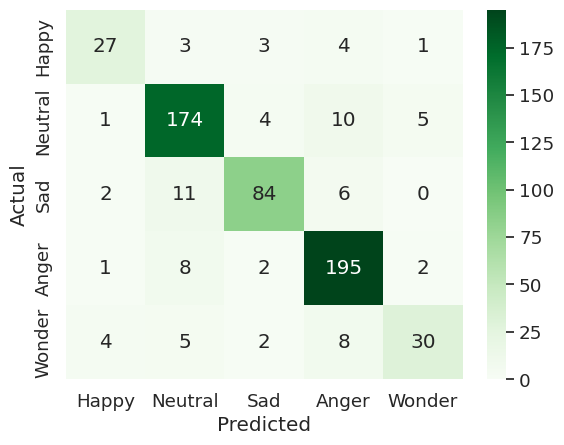

Testing finished with Loss: 0.46279019847310876 | U_Accuracy: 0.7945424821652054 | W_Accuracy: 0.8614864864864865 | Precision: 0.8596214307944922 | Recall: 0.8614864864864865 | f1: 0.8588286227298645
Accuracy per class:
Class 0: 0.7105263157894737
Class 1: 0.8969072164948454
Class 2: 0.8155339805825242
Class 3: 0.9375
Class 4: 0.6122448979591837


In [17]:
reset_seed(42)
for i, (train_loader, val_loader) in enumerate(loader_lists):
    model = GRUModel(num_layers=2 ,b_directional=True)

    for param in model.parameters():
        param.requires_grad = False

    for param in model.projector.parameters():
        param.requires_grad = True

    for param in model.gru.parameters():
        param.requires_grad = True

    for param in model.classifier.parameters():
        param.requeres_grad = True

    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    training_losses0, valid_losses0 = train(model, f'whisper_gru_simple_fold{i +1}', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader,epochs=10, patience=10)

    plt.plot(training_losses0, label='Training Loss')
    plt.plot(valid_losses0, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    model.load_state_dict(torch.load(f'whisper_gru_simple_fold{i +1}.bin'))
    test(model, torch.nn.CrossEntropyLoss(), val_loader)